In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import time,tracemalloc


In [ ]:
path = '..../KDDTrain+.arff'
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
df['label'] = (df[df.columns[-1]] != 'normal').astype(int)

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 43
Total missing    : 0
Affected columns : 0


In [5]:
selected_features = [
    'num_access_files',
    'dst_bytes',
    'dst_host_count',
    'num_compromised',
    'dst_host_same_srv_rate',
    'same_srv_rate',
    'dst_host_srv_count',
    'serror_rate',
    'count',
    'rerror_rate',
    'dst_host_srv_rerror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_same_src_port_rate',
    'dst_host_serror_rate',
    'num_file_creations',
    'srv_count',
    'srv_serror_rate',
    'srv_rerror_rate',
    'srv_diff_host_rate',
    'wrong_fragment',
    'urgent',
    'src_bytes',
    'hot',
    'num_failed_logins'
]

print(f"Total features: {len(selected_features)}")

Total features: 25


In [6]:
label_encoder = LabelEncoder()
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['flag'] = label_encoder.fit_transform(df['flag'])

In [7]:
X = df[selected_features].values
y = df.iloc[:, 42].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# --- JaspenCorrelation Layer ---
class JaspenCorrelation(tf.keras.layers.Layer):
    def call(self, inputs):
        t, r = inputs  # t: (None, feat_dim), r: (None, REF_COUNT, feat_dim)
        t_exp = tf.expand_dims(t, 1)  # (None, 1, feat_dim)
        dot = tf.reduce_sum(t_exp * r, axis=2)  # (None, REF_COUNT)

        sum_t = tf.reduce_sum(t_exp, axis=2)  # (None, 1)
        sum_r = tf.reduce_sum(r, axis=2)      # (None, REF_COUNT)

        n = tf.cast(tf.shape(t)[1], tf.float32)
        corr = (n * dot - sum_t * sum_r) / (tf.sqrt(n * sum_t) * tf.sqrt(n * sum_r) + 1e-8)
        return tf.maximum(corr, 0.0)  # only positive correlation

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_test = X_test.reshape(-1, X_test.shape[1], 1)

SEQ_LEN = X_train.shape[1]
CHANNELS = 1
REF_COUNT = 30
NUM_CLASSES = y_train.shape[1]

In [9]:

# --- Inputs ---
test_input = Input(shape=(SEQ_LEN, CHANNELS), name="test_input")
reference_input = Input(shape=(REF_COUNT, SEQ_LEN, CHANNELS), name="reference_input")

# --- Shared CNN ---
shared_cnn = tf.keras.Sequential([
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten()
], name='shared_cnn')

# Apply shared CNN
test_encoded = shared_cnn(test_input)  # (None, feat_dim)
reference_encoded = TimeDistributed(shared_cnn)(reference_input)  # (None, REF_COUNT, feat_dim)

# --- Correlation ---
corr = JaspenCorrelation()([test_encoded, reference_encoded])  # (None, REF_COUNT)
agg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(corr)  # (None, 1)

# --- Dense Output ---
x = Dense(128, activation='relu')(agg)
output = Dense(NUM_CLASSES, activation='sigmoid')(x)

model = Model(inputs=[test_input, reference_input], outputs=output)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ test_input          │ (None, 25, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reference_input     │ (None, 30, 25, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_cnn          │ (None, 512)       │     24,960 │ test_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 30, 512)   │     24,960 │ reference_input[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jaspen_correlation  │ (None, 30)        │          0 │ shared_cnn[0][0], │
│ (JaspenCorrelation) │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ jaspen_correlati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,474 (99.51 KB)

 Trainable params: 25,474 (99.51 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Get 30 random reference from training set
reference_set = X_train[:REF_COUNT]  # (10, SEQ_LEN, 1)
reference_input_train = np.repeat(reference_set[np.newaxis, :, :, :], X_train.shape[0], axis=0)
reference_input_test = np.repeat(reference_set[np.newaxis, :, :, :], X_test.shape[0], axis=0)
start = time.time()
tracemalloc.start()
# Train
history = model.fit(
    [X_train, reference_input_train],
    y_train,
    validation_data=([X_test, reference_input_test], y_test),
    epochs=10,
    batch_size=32
)
end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

Epoch 1/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 77s 16ms/step - accuracy: 0.9369 - loss: 0.1742 - val_accuracy: 0.9595 - val_loss: 0.1170
Epoch 2/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.9621 - loss: 0.1133 - val_accuracy: 0.9672 - val_loss: 0.1053
Epoch 3/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.9638 - loss: 0.1018 - val_accuracy: 0.9632 - val_loss: 0.0957
Epoch 4/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.9660 - loss: 0.0899 - val_accuracy: 0.9560 - val_loss: 0.1070
Epoch 5/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9682 - loss: 0.0815 - val_accuracy: 0.9711 - val_loss: 0.0766
Epoch 6/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.9705 - loss: 0.0757 - val_accuracy: 0.9678 - val_loss: 0.0779
Epoch 7/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.9715 - loss: 0.0725 - val_accuracy: 0.9716 - val_loss: 0.0710
Epoch 8/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9726 -

In [11]:
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9748 - loss: 0.0630
Test Loss: 0.0630, Test Accuracy: 0.9748


In [12]:
print(f"Memory usage: Current = {current / 10**6:.2f} MB; Peak = {peak / 10**6:.2f} MB")

Memory usage: Current = 12.83 MB; Peak = 627.10 MB


In [13]:
y_pred = model.predict([X_test, reference_input_test])
y_pred_binary = (y_pred > 0.5).astype(int)


788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step


In [14]:
y_true_binary = y_test.astype(int)
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP + 1e-8)
print(f"Specificity: {specificity:.4f}")

Specificity: 0.9748


In [15]:
y_pred = model.predict([X_test, reference_input_test])
y_pred_binary = (y_pred > 0.5).astype(int)
if y_test.shape[1] > 1:
    y_test_binary = np.argmax(y_test, axis=1)
    y_pred_binary = np.argmax(y_pred_binary, axis=1)

# Calculate Evaluation Metrics
precision = precision_score(y_test_binary, y_pred_binary, average='binary')
recall = recall_score(y_test_binary, y_pred_binary, average='binary')
f1 = f1_score(y_test_binary, y_pred_binary, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Precision: 0.9823
Recall: 0.9633
F1-Score: 0.9727
Specificity: 0.9748


In [16]:
eval_start = time.time()
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
eval_end = time.time()
pred_start = time.time()
y_pred = model.predict([X_test, reference_input_test])
pred_end = time.time()

788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9748 - loss: 0.0630
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [17]:

total_epochs = 10
batch_size = 32
total_samples_train = len(X_train)
total_samples_test = len(X_test)
total_batches_per_epoch = total_samples_train // batch_size


print(f"Training time per epoch: {(end - start) / total_epochs:.2f} seconds")
print(f"Training time per sample: {(end - start) / total_samples_train * 1000:.2f} ms")
print(f"Training time per batch: {(end - start) / (total_epochs * total_batches_per_epoch) * 1000:.2f} ms")
print(f"Prediction time per sample: {(pred_end - pred_start) / total_samples_test * 1000:.2f} ms")

Training time per epoch: 38.27 seconds
Training time per sample: 3.80 ms
Training time per batch: 12.15 ms
Prediction time per sample: 0.10 ms


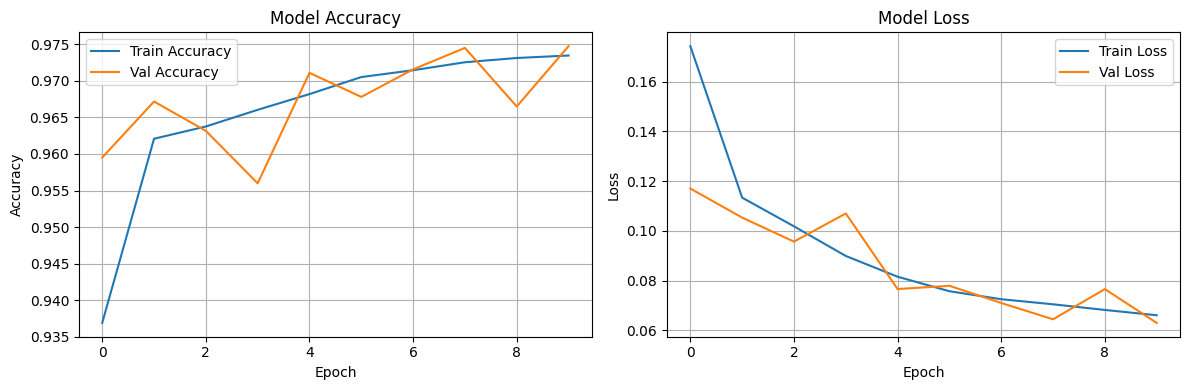

In [18]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()